# 3 Data Preparation

This notebook documents the data preparation stage of the project **Predicting High Health Risk Among Older Adults Using Machine Learning**. The dataset was constructed using selected NHANES 2021–2023 files, including demographic, chronic disease, health status, functional limitation, and smoking-related variables. Only respondents aged 65 years and above were retained for this study.

The objective of this notebook is to transform the raw merged data into a final analytical dataset suitable for machine learning modelling. To achieve this, several preprocessing steps were carried out, including variable screening, missing value inspection, simplified variable selection, variable recoding, construction of a smoking-related predictor, and definition of the target variable.


## 3.1 Check Data and merged

###  3.1.1 Check

In [33]:
import pandas as pd
demo = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/DEMO_L.xpt", format="xport")
mcq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/MCQ_L.xpt", format="xport")
bpq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/BPQ_L.xpt", format="xport")
diq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/DIQ_L.xpt", format="xport")
huq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/HUQ_L.xpt", format="xport")
fnq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/FNQ_L.xpt", format="xport")
smq = pd.read_sas("/Users/gaoshangxiao/Desktop/WQD7003-Group8-AgingSociety/data/SMQ_L.xpt", format="xport")

In [34]:
print("demo:", demo.shape) ## Data volume
print("mcq:", mcq.shape)
print("bpq:", bpq.shape)
print("diq:", diq.shape)
print("huq:", huq.shape)
print("fnq:", fnq.shape)
print("smq:", smq.shape)

demo: (11933, 27)
mcq: (11744, 35)
bpq: (8501, 6)
diq: (11744, 9)
huq: (11933, 6)
fnq: (10942, 32)
smq: (9015, 9)


In [35]:
print("SEQN in demo:", "SEQN" in demo.columns) ## check SEQN
print("SEQN in mcq:", "SEQN" in mcq.columns)
print("SEQN in bpq:", "SEQN" in bpq.columns)
print("SEQN in diq:", "SEQN" in diq.columns)
print("SEQN in huq:", "SEQN" in huq.columns)
print("SEQN in fnq:", "SEQN" in fnq.columns)
print("SEQN in smq:", "SEQN" in fnq.columns)

SEQN in demo: True
SEQN in mcq: True
SEQN in bpq: True
SEQN in diq: True
SEQN in huq: True
SEQN in fnq: True
SEQN in smq: True


### 3.1.2 merged

In [5]:
## Screening the elderly aged 65 and above
elderly_demo = demo[demo["RIDAGEYR"] >= 65].copy()
print(elderly_demo.shape)
elderly_demo.head()

(2586, 27)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHRGND,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVSTRA,SDMVPSU,INDFMPIR
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,29087.450605,3.408472e+04,173.0,2.0,5.00
7,130385.0,12.0,1.0,2.0,65.0,NaN,3.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,16151.033173,5.397605e-79,187.0,2.0,5.00
9,130387.0,12.0,2.0,2.0,68.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,19896.970559,2.077625e+04,181.0,1.0,1.32
14,130392.0,12.0,2.0,2.0,74.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,25064.248864,2.942777e+04,174.0,1.0,3.04
19,130397.0,12.0,2.0,2.0,67.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,32394.280442,3.803740e+04,179.0,2.0,4.48


In [36]:
merged = elderly_demo.merge(mcq, on="SEQN", how="left")
merged = merged.merge(bpq, on="SEQN", how="left")
merged = merged.merge(diq, on="SEQN", how="left")
merged = merged.merge(huq, on="SEQN", how="left")
merged = merged.merge(fnq, on="SEQN", how="left")
merged = merged.merge(smq, on="SEQN", how="left")
print(merged.shape)
merged.head()

(2586, 118)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,FNDADI,FNDAEDI,SMQ020,SMQ040,SMD641,SMD650,SMD100MN,SMQ621,SMD630,SMAQUEX2
0,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,2.0,2.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0
1,130385.0,12.0,1.0,2.0,65.0,NaN,3.0,3.0,NaN,NaN,...,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,130387.0,12.0,2.0,2.0,68.0,NaN,3.0,3.0,2.0,NaN,...,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,130392.0,12.0,2.0,2.0,74.0,NaN,3.0,3.0,2.0,NaN,...,2.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,130397.0,12.0,2.0,2.0,67.0,NaN,3.0,3.0,1.0,NaN,...,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [48]:
print(merged.columns.tolist())

['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDAGEMN', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'RIDEXAGM', 'DMQMILIZ', 'DMDBORN4', 'DMDYRUSR', 'DMDEDUC2', 'DMDMARTZ', 'RIDEXPRG', 'DMDHHSIZ', 'DMDHRGND', 'DMDHRAGZ', 'DMDHREDZ', 'DMDHRMAZ', 'DMDHSEDZ', 'WTINT2YR', 'WTMEC2YR', 'SDMVSTRA', 'SDMVPSU', 'INDFMPIR', 'MCQ010', 'MCQ035', 'MCQ040', 'MCQ050', 'AGQ030', 'MCQ053', 'MCQ149', 'MCQ160A', 'MCQ195', 'MCQ160B', 'MCQ160C', 'MCQ160D', 'MCQ160E', 'MCQ160F', 'MCQ160M', 'MCQ170M', 'MCQ160P', 'MCQ160L', 'MCQ170L', 'MCQ500', 'MCQ510A', 'MCQ510B', 'MCQ510C', 'MCQ510D', 'MCQ510E', 'MCQ510F', 'MCQ550', 'MCQ560', 'MCQ220', 'MCQ230A', 'MCQ230B', 'MCQ230C', 'MCQ230D', 'OSQ230', 'BPQ020', 'BPQ030', 'BPQ150', 'BPQ080', 'BPQ101D', 'DIQ010', 'DID040', 'DIQ160', 'DIQ180', 'DIQ050', 'DID060', 'DIQ060U', 'DIQ070', 'HUQ010', 'HUQ030', 'HUQ042', 'HUQ055', 'HUQ090', 'FNQ021', 'FNQ041', 'FNQ050', 'FNQ060', 'FNQ080', 'FNQ160', 'FNQ100', 'FNQ110', 'FNQ120', 'FNQ170', 'FNQ180', 'FNQ190', 'FNQ130', 'FNQ200

## 3.2 Full Variables and Codebook Descriptions

### 3.2.1 Demographic Variables

| Variable | Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Unique respondent identifier used for merging datasets |
| SDDSRVYR | Data release cycle | Survey cycle information |
| RIDSTATR | Interview/Examination status | Participant interview and examination status |
| RIAGENDR | Gender | Demographic feature |
| RIDAGEYR | Age in years at screening | Used to filter participants aged 65 and above |
| RIDAGEMN | Age in months at screening (0 to 24 months) | Applicable mainly to infants/young children |
| RIDRETH1 | Race/Hispanic origin | Demographic feature |
| RIDRETH3 | Race/Hispanic origin with NH Asian | Extended race/ethnicity classification |
| RIDEXMON | Six-month time period | Examination period indicator |
| RIDEXAGM | Age in months at exam (0 to 19 years) | Mainly for children/adolescents |
| DMQMILIZ | Served active duty in US Armed Forces | Military service variable |
| DMDBORN4 | Country of birth | Demographic feature |
| DMDYRUSR | Length of time in US | Immigration-related variable |
| DMDEDUC2 | Education level - Adults 20+ | Socioeconomic feature |
| DMDMARTZ | Marital status | Demographic feature |
| RIDEXPRG | Pregnancy status at exam | Mainly relevant to female participants of childbearing age |
| DMDHHSIZ | Total number of people in household | Household structure variable |
| DMDHRGND | Household reference person’s gender | Household-level variable |
| DMDHRAGZ | Household reference person’s age in years | Household-level variable |
| DMDHREDZ | Household reference person’s education level | Household-level variable |
| DMDHRMAZ | Household reference person’s marital status | Household-level variable |
| DMDHSEDZ | Household reference person’s spouse’s education level | Household-level variable |
| WTINT2YR | Full sample 2-year interview weight | Sampling weight variable |
| WTMEC2YR | Full sample 2-year MEC exam weight | Sampling weight variable |
| SDMVSTRA | Masked variance pseudo-stratum | Survey design variable |
| SDMVPSU | Masked variance pseudo-PSU | Survey design variable |
| INDFMPIR | Ratio of family income to poverty | Socioeconomic feature |

### 3.2.2 Medical Conditions Variables

| Variable | Description | Notes |
|---|---|---|
| MCQ010 | Ever been told you have asthma | Chronic respiratory condition |
| MCQ035 | Still have asthma | Current asthma status |
| MCQ040 | Had asthma attack in past year | Asthma severity indicator |
| MCQ050 | Emergency care visit for asthma / past year | Healthcare utilization related to asthma |
| AGQ030 | Did SP have episode of hay fever / past year | Allergy-related condition |
| MCQ053 | Taking treatment for anemia / past 3 months | Recent treatment variable |
| MCQ149 | Menstrual periods started yet? | Biological history variable; likely not relevant for elderly analysis |
| MCQ160A | Doctor ever said you had arthritis | Chronic musculoskeletal condition |
| MCQ160B | Ever told had congestive heart failure | Cardiovascular disease variable |
| MCQ160C | Ever told you had coronary heart disease | Cardiovascular disease variable |
| MCQ160D | Ever told you had angina / angina pectoris | Cardiovascular disease variable |
| MCQ160E | Ever told you had heart attack | Cardiovascular disease variable |
| MCQ160F | Ever told you had a stroke | Cardiovascular / neurological disease variable |
| MCQ160M | Ever told you had thyroid problem | Chronic disease variable |
| MCQ160P | Ever told you had COPD, emphysema, or chronic bronchitis | Chronic respiratory disease variable |
| MCQ160L | Ever told you had any liver condition | Chronic disease variable |
| MCQ170M | Do you still have thyroid problem | Current thyroid condition |
| MCQ170L | Do you still have a liver condition | Current liver condition |
| MCQ500 | Ever told you had any liver condition | Liver disease screening variable |
| MCQ510A | Liver condition: Fatty liver | Specific liver disease type |
| MCQ510B | Liver condition: Liver fibrosis | Specific liver disease type |
| MCQ510C | Liver condition: Liver cirrhosis | Specific liver disease type |
| MCQ510D | Liver condition: Viral hepatitis | Specific liver disease type |
| MCQ510E | Liver condition: Autoimmune hepatitis | Specific liver disease type |
| MCQ510F | Liver condition: Other liver disease | Specific liver disease type |
| MCQ550 | Has doctor ever said you have gallstones | Gallbladder-related condition |
| MCQ560 | Ever had gallbladder surgery? | Surgical history variable |
| MCQ220 | Ever told you had cancer or malignancy | Major chronic disease variable |
| MCQ230A | 1st cancer - what kind was it? | Cancer type detail |
| MCQ230B | 2nd cancer - what kind was it? | Cancer type detail |
| MCQ230C | 3rd cancer - what kind was it? | Cancer type detail |
| MCQ230D | More than 3 kinds of cancer | Cancer history detail |
| OSQ230 | Any metal objects inside your body? | Medical history / examination-related variable |

### 3.2.3 Blood Pressure and Cholesterol Variables

| Variable | Description | Notes |
|---|---|---|
| BPQ020 | Ever told you had high blood pressure | Core chronic disease variable |
| BPQ030 | Told had high blood pressure 2+ times | Hypertension confirmation variable |
| BPQ150 | Taking high blood pressure medication | Hypertension treatment variable |
| BPQ080 | Doctor told you - high cholesterol level | Lipid disorder variable |
| BPQ101D | Taking meds to lower blood cholesterol | Cholesterol treatment variable |

### 3.2.4 Diabetes Variables

| Variable | Description | Notes |
|---|---|---|
| DIQ010 | Doctor told you have diabetes | Core chronic disease variable |
| DID040 | Age when first told you had diabetes | Diabetes history variable |
| DIQ160 | Ever told you have prediabetes | Additional metabolic risk variable |
| DIQ180 | Had blood tested past three years | Health monitoring variable |
| DIQ050 | Taking insulin now | Diabetes treatment variable |
| DID060 | How long taking insulin | Diabetes treatment duration |
| DIQ060U | Unit of measure (month/year) | Time unit for insulin duration |
| DIQ070 | Take diabetic pills to lower blood sugar | Diabetes treatment variable |

### 3.2.5 Hospital Utilization and Access to Care Variables

| Variable | Description | Notes |
|---|---|---|
| HUQ010 | General health condition | Important health status variable |
| HUQ030 | Routine place to go for healthcare | Healthcare access variable |
| HUQ042 | Type place most often go for healthcare | Healthcare service usage variable |
| HUQ055 | Past 12 months had video conference with doctor | Telehealth / healthcare access variable |
| HUQ090 | Seen mental health professional / past year | Mental healthcare utilization variable |

### 3.2.6 Functioning Variables

| Variable | Description | Notes |
|---|---|---|
| FNQ021 | Difficulty seeing even with glasses | Functional limitation variable |
| FNQ041 | Difficulty hearing even with hearing aids | Functional limitation variable |
| FNQ050 | Use equipment or assistance for walking | Mobility support variable |
| FNQ060 | Difficulty walking 100 yards without equipment | Mobility limitation variable |
| FNQ080 | Difficulty walking 100 yards | Mobility limitation variable |
| FNQ160 | Difficulty with self-care | Functional limitation variable |
| FNQ100 | Difficulty being understood inside household | Communication limitation variable |
| FNQ110 | Difficulty being understood outside household | Communication limitation variable |
| FNQ120 | Difficulty learning things | Cognitive limitation variable |
| FNQ170 | Difficulty remembering things | Cognitive limitation variable |
| FNQ180 | Difficulty concentrating | Cognitive limitation variable |
| FNQ190 | Difficulty accepting change | Behavioral / cognitive limitation variable |
| FNQ130 | Difficulty controlling behavior | Behavioral limitation variable |
| FNQ200 | Difficulty making friends | Social functioning variable |
| FNQ140 | How often very anxious / nervous / worried | Mental health frequency variable |
| FNQ150 | How often very sad / depressed | Mental health frequency variable |
| FNQDCDI* | CFM Disability Indicator for 5–17 years | Present in merged columns list; verify exact spelling in dataset if needed |
| FNQ410 | Difficulty seeing even with glasses | Adult functioning variable |
| FNQ430 | Difficulty hearing even with hearing aids | Adult functioning variable |
| FNQ440 | Difficulty walking or climbing steps | Mobility limitation variable |
| FNQ450 | Difficulty communicating | Communication limitation variable |
| FNQ460 | Difficulty remembering or concentrating | Cognitive limitation variable |
| FNQ470 | Difficulty with self-care | Daily living limitation variable |
| FNQ480 | Difficulty raising a 2-liter bottle | Upper-body functioning variable |
| FNQ490 | Difficulty using hands and fingers | Fine motor limitation variable |
| FNQ510 | How often feel worried / nervous / anxious | Mental health frequency variable |
| FNQ520 | Level of feeling worried / nervous / anxious | Mental health severity variable |
| FNQ530 | How often feel depressed | Mental health frequency variable |
| FNQ540 | Level of feeling depressed | Mental health severity variable |
| FNDADI | WG-SS Disability Indicator 18+ | Disability indicator for adults |
| FNDAEDI | WG-SS Enhanced Disability Indicator 18+ | Enhanced disability indicator for adults |
### 3.5.7 Smoking Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Unique identifier used to merge this dataset with other NHANES files |
| SMQ020 | Smoked at least 100 cigarettes in life | Smoking history variable used to identify lifetime smoking experience |
| SMQ040 | Do you now smoke cigarettes? | Current smoking status variable |
| SMD641 | Number of days smoked in past 30 days | Indicates smoking frequency in the past 30 days |
| SMD650 | Average number of cigarettes smoked per day in past 30 days | Indicates average daily cigarette consumption in the past 30 days |
| SMD100MN | Menthol cigarette indicator | Indicates whether the cigarettes smoked were menthol cigarettes |
| SMQ621 | Number of cigarettes smoked in life | Describes lifetime cigarette consumption |
| SMD630 | Age first started smoking regular cigarettes | Indicates the age when the respondent first started smoking whole cigarettes regularly |
| SMAQUEX2 | Questionnaire mode flag | Indicates the questionnaire mode or survey administration format |

## 3.3 Initial Variable Screening

After merging the datasets, an initial variable screening step was conducted. A total of 48 candidate variables were retained based on their relevance to the study objective, including demographic variables, chronic disease variables, healthcare-related variables, functional limitation variables, and one smoking-related variable. These variables were then used for missing value inspection before further simplification.

In [63]:
# Keep 48 candidate variables for further missing value inspection

keep_cols = [
    # ID
    'SEQN',

    # Demographic variables
    'RIAGENDR',
    'RIDAGEYR',
    'RIDRETH1',
    'INDFMPIR',

    # General health
    'HUQ010',
    'HUQ030',
    'HUQ042',
    'HUQ090',

    # Diabetes-related variables
    'DIQ010',
    'DIQ160',
    'DIQ050',
    'DIQ070',

    # Blood pressure / cholesterol variables
    'BPQ020',
    'BPQ030',
    'BPQ150',
    'BPQ080',
    'BPQ101D',

    # Medical condition variables
    'MCQ160A',
    'MCQ160B',
    'MCQ160C',
    'MCQ160D',
    'MCQ160E',
    'MCQ160F',
    'MCQ160P',
    'MCQ160L',
    'MCQ220',
    'MCQ550',
    'MCQ560',

    # Functional limitation variables
    'FNQ050',
    'FNQ060',
    'FNQ080',
    'FNQ160',
    'FNQ170',
    'FNQ180',
    'FNQ410',
    'FNQ430',
    'FNQ440',
    'FNQ450',
    'FNQ460',
    'FNQ470',
    'FNQ480',
    'FNQ490',
    'FNQ510',
    'FNQ530',
    'FNDADI',
    'FNDAEDI',

    # Smoking variable
    'SMQ040',
    'SMQ020'

]

# Create the candidate-variable dataset
selected = merged[keep_cols].copy()

# Check the shape of the selected dataset
print("Selected dataset shape:", selected.shape)

# Preview the first few rows
selected.head()

Selected dataset shape: (2586, 49)


,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,INDFMPIR,HUQ010,HUQ030,HUQ042,HUQ090,DIQ010,...,FNQ460,FNQ470,FNQ480,FNQ490,FNQ510,FNQ530,FNDADI,FNDAEDI,SMQ040,SMQ020
0,130379.0,1.0,66.0,3.0,5.00,3.0,1.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,4.0,5.0,2.0,2.0,3.0,1.0
1,130385.0,2.0,65.0,3.0,5.00,2.0,1.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,4.0,2.0,2.0,NaN,2.0
2,130387.0,2.0,68.0,3.0,1.32,2.0,1.0,2.0,2.0,2.0,...,1.0,2.0,1.0,1.0,2.0,5.0,2.0,2.0,NaN,2.0
3,130392.0,2.0,74.0,3.0,3.04,2.0,1.0,1.0,2.0,2.0,...,1.0,1.0,1.0,3.0,4.0,4.0,2.0,1.0,NaN,2.0
4,130397.0,2.0,67.0,3.0,4.48,3.0,1.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,NaN,2.0


## 3.4 Missing Value Inspection

In [64]:
# Check missing values for the 48 candidate variables
missing = selected.isnull().sum().sort_values(ascending=False)
print(missing)

FNQ050      2586
FNQ060      2586
FNQ080      2586
FNQ160      2586
FNQ170      2586
FNQ180      2586
DIQ050      2029
DIQ070      1538
SMQ040      1328
BPQ150      1064
BPQ030      1064
DIQ160       685
INDFMPIR     470
HUQ042       118
FNQ430         2
FNDAEDI        2
FNDADI         2
FNQ530         2
FNQ410         2
FNQ440         2
FNQ490         2
FNQ450         2
FNQ460         2
FNQ470         2
FNQ510         2
FNQ480         2
SMQ020         2
MCQ560         1
MCQ160P        1
MCQ550         1
MCQ220         1
DIQ010         1
BPQ020         1
BPQ080         1
BPQ101D        1
MCQ160L        1
MCQ160D        0
MCQ160C        0
MCQ160B        0
MCQ160A        0
MCQ160E        0
MCQ160F        0
RIAGENDR       0
HUQ090         0
HUQ030         0
HUQ010         0
RIDRETH1       0
RIDAGEYR       0
SEQN           0
dtype: int64


Missing values were inspected for the simplified variable set before further preprocessing. A missing value pattern plot was created to visualize the distribution of missingness across the retained variables. This step helped identify whether any of the final selected predictors still contained substantial missing data before variable recoding and target construction.

### Figure1:Missing Value Pattern

The merged dataset initially contained 118 variables. To reduce complexity and focus on variables relevant to the study objective, an initial variable screening step was performed. Variables related to demographic characteristics, chronic diseases, health status, healthcare access, and functioning were retained for further analysis. As a result, 48 variables were selected for the next stage of preprocessing.

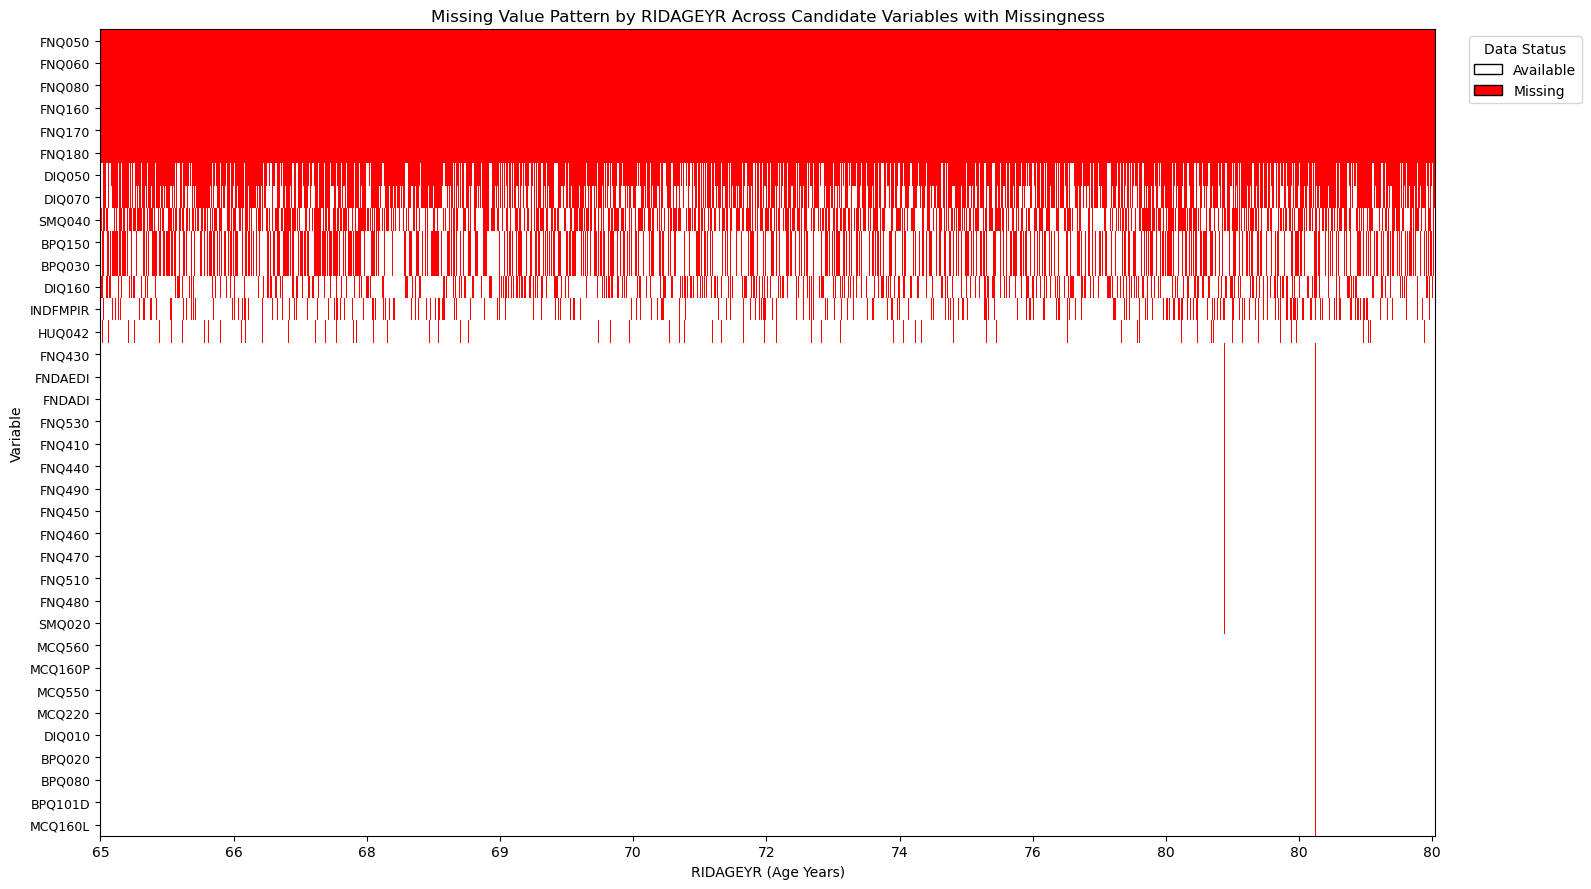

In [68]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Step 1: calculate missing values for the 49 candidate variables
missing = selected.isnull().sum().sort_values(ascending=False)

# Step 2: keep only variables with missing values
plot_vars = missing[missing > 0].index.tolist()

# Remove ID variable if it appears
if 'SEQN' in plot_vars:
    plot_vars.remove('SEQN')

# RIDAGEYR will be used on the x-axis, so remove it from y-axis variables
if 'RIDAGEYR' in plot_vars:
    plot_vars.remove('RIDAGEYR')

# Step 3: create plotting dataframe
plot_df = selected[['RIDAGEYR'] + plot_vars].copy()

# Step 4: sort by age
plot_df = plot_df.sort_values(by='RIDAGEYR').reset_index(drop=True)

# Step 5: create missing-value matrix
# missing = 1, available = 0
missing_matrix = plot_df.drop(columns=['RIDAGEYR']).isnull().T.astype(int)

# Step 6: define colors
# white = available, red = missing
cmap = ListedColormap(['white', 'red'])

# Step 7: plot
plt.figure(figsize=(16, 9))
plt.imshow(missing_matrix, aspect='auto', interpolation='none', cmap=cmap)

# y-axis labels
plt.yticks(range(len(missing_matrix.index)), missing_matrix.index, fontsize=9)

# x-axis labels based on age
x_positions = range(0, len(plot_df), max(1, len(plot_df)//10))
x_labels = plot_df.loc[list(x_positions), 'RIDAGEYR'].astype(int).tolist()
plt.xticks(x_positions, x_labels)

plt.xlabel('RIDAGEYR (Age Years)')
plt.ylabel('Variable')
plt.title('Missing Value Pattern by RIDAGEYR Across Candidate Variables with Missingness')

# legend
legend_elements = [
    Patch(facecolor='white', edgecolor='black', label='Available'),
    Patch(facecolor='red', edgecolor='black', label='Missing')
]
plt.legend(handles=legend_elements, title='Data Status',
           bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

This figure does not display all 49 selected variables. Instead, it focuses on a subset of variables with relatively high missingness. The purpose of the figure is to visualize the pattern of missing data among the most affected variables and to support decisions on variable removal in the later preprocessing stage.

## 3.5 Variable Recoding and Target Construction

After the missing value inspection, the variable list was further reduced from 48 variables to 21 variables. This reduction was not based only on missingness, but also on the need to simplify the model design and improve interpretability.

First, variables with excessive missing values were removed because they provided limited usable information for the elderly sample. Second, the remaining variables were further simplified according to the project design. Only one representative variable was retained for each major disease category whenever possible. In addition, only a small number of common and meaningful functional limitation variables among older adults were selected. This approach helped avoid redundancy and made the predictor set more consistent with the study objective.

As a result, the final simplified dataset included demographic variables, one general health-related variable, one representative variable for each major disease category, selected cardiovascular disease variables to be combined later, and three functional limitation indicators.

In [67]:
keep_cols_simple = [
    'SEQN',
    'RIAGENDR',
    'RIDAGEYR',
    'RIDRETH1',
    'INDFMPIR',
    'HUQ010',
    'DIQ010',
    'BPQ020',
    'BPQ080',
    'MCQ160A',
    'MCQ160P',
    'MCQ220',
    'MCQ160B',
    'MCQ160C',
    'MCQ160D',
    'MCQ160E',
    'MCQ160F',
    'FNQ440',
    'FNQ470',
    'FNQ480',
    'SMQ040',
    'SMQ020'
]

selected_simple = merged[keep_cols_simple].copy()
print(selected_simple.shape)

(2586, 22)


### 3.5.1 Demographic Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| SEQN | Respondent sequence number | Unique respondent identifier used for merging datasets |
| RIAGENDR | Gender | Demographic feature |
| RIDAGEYR | Age in years at screening | Used to retain participants aged 65 and above |
| RIDRETH1 | Race/Hispanic origin | Demographic feature |
| INDFMPIR | Ratio of family income to poverty | Socioeconomic feature |

### 3.5.2 Health Status Variable

| Variable | Codebook Description | Notes |
|---|---|---|
| HUQ010 | General health condition | Used as the target variable proxy in this study |

### 3.5.3 Disease Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| DIQ010 | Doctor told you have diabetes | Representative diabetes variable |
| BPQ020 | Ever told you had high blood pressure | Representative hypertension variable |
| BPQ080 | Doctor told you - high cholesterol level | Representative high cholesterol variable |
| MCQ160A | Doctor ever said you had arthritis | Representative arthritis variable |
| MCQ160P | Ever told you had COPD, emphysema, chronic bronchitis | Representative respiratory disease variable |
| MCQ220 | Ever told you had cancer or malignancy | Representative cancer variable |

### 3.5.4 Cardiovascular Disease Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| MCQ160B | Ever told had congestive heart failure | Cardiovascular disease variable |
| MCQ160C | Ever told you had coronary heart disease | Cardiovascular disease variable |
| MCQ160D | Ever told you had angina/angina pectoris | Cardiovascular disease variable |
| MCQ160E | Ever told you had heart attack | Cardiovascular disease variable |
| MCQ160F | Ever told you had a stroke | Cardiovascular / neurological disease variable |

### 3.5.5 Functional Limitation Variables

| Variable | Codebook Description | Notes |
|---|---|---|
| FNQ440 | Difficulty walking or climbing steps | Functional limitation variable |
| FNQ470 | Difficulty with self-care | Functional limitation variable |
| FNQ480 | Difficulty raising a 2-liter bottle | Functional limitation variable |
### 3.5.6 Smoking Variable


| Variable | Codebook Description | Notes |
|---|---|---|
| SMQ020 | Smoked at least 100 cigarettes in life | Smoking history variable |
| SMQ040 | Do you now smoke cigarettes? | Current smoking variable; later used together with SMQ020 to construct smoking status |

## 3.6 Variable Recoding and Target Construction

After the simplified variable selection step, the retained variables were recoded to prepare the dataset for machine learning analysis. Special response codes such as `7`, `9`, and `99`, which usually represent refused, unknown, or inapplicable responses in NHANES, were treated as missing values.

Binary disease variables were recoded into a consistent `1 = Yes` and `0 = No` format. The smoking-related predictor was derived using both `SMQ020` and `SMQ040`. This was done because `SMQ040` alone contained many missing values due to the survey skip pattern. A new binary variable, `smoking_status`, was created to represent current smoker versus non-smoker.

The cardiovascular disease variables were combined into one new binary variable, `cardio_disease`, to indicate whether the participant had any major cardiovascular condition. The selected functional limitation variables were also simplified into binary indicators. For these variables, `1` was treated as no difficulty, while `2`, `3`, and `4` were grouped into difficulty or limitation.

Finally, the target variable was defined for the classification task. In this study, `HUQ010` was transformed into a binary outcome, where participants reporting fair or poor health were classified as `1`, while those reporting excellent, very good, or good health were classified as `0`.

In [69]:
selected_simple

,SEQN,RIAGENDR,RIDAGEYR,RIDRETH1,INDFMPIR,HUQ010,DIQ010,BPQ020,BPQ080,MCQ160A,...,MCQ160B,MCQ160C,MCQ160D,MCQ160E,MCQ160F,FNQ440,FNQ470,FNQ480,SMQ040,SMQ020
0,130379.0,1.0,66.0,3.0,5.00,3.0,2.0,1.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,1.0
1,130385.0,2.0,65.0,3.0,5.00,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,NaN,2.0
2,130387.0,2.0,68.0,3.0,1.32,2.0,2.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,NaN,2.0
3,130392.0,2.0,74.0,3.0,3.04,2.0,2.0,1.0,2.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,NaN,2.0
4,130397.0,2.0,67.0,3.0,4.48,3.0,2.0,2.0,1.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2581,142301.0,2.0,80.0,3.0,1.20,2.0,2.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3.0,1.0
2582,142302.0,1.0,70.0,3.0,2.33,2.0,2.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,1.0
2583,142303.0,2.0,69.0,5.0,0.98,3.0,1.0,2.0,9.0,1.0,...,2.0,2.0,2.0,2.0,1.0,3.0,1.0,1.0,3.0,1.0
2584,142305.0,2.0,76.0,1.0,2.25,4.0,3.0,1.0,1.0,1.0,...,2.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,NaN,2.0


In [70]:
import pandas as pd

# 1. Replace special response codes with missing values
selected_simple = selected_simple.replace({
    7: pd.NA, 9: pd.NA, 99: pd.NA,
    7.0: pd.NA, 9.0: pd.NA, 99.0: pd.NA
})

# 2. Recode binary disease variables into 1 = Yes, 0 = No
yes_no_cols = [
    'DIQ010',
    'BPQ020',
    'BPQ080',
    'MCQ160A',
    'MCQ160P',
    'MCQ220',
    'MCQ160B',
    'MCQ160C',
    'MCQ160D',
    'MCQ160E',
    'MCQ160F'
]

for col in yes_no_cols:
    selected_simple[col] = selected_simple[col].replace({1.0: 1, 2.0: 0})

# 3. Create smoking_status using both SMQ020 and SMQ040
# SMQ020: smoked at least 100 cigarettes in life
# SMQ040: do you now smoke cigarettes?

selected_simple['smoking_status'] = pd.NA

# current smoker: every day or some days
selected_simple.loc[selected_simple['SMQ040'].isin([1.0, 2.0]), 'smoking_status'] = 1

# not currently smoking
selected_simple.loc[selected_simple['SMQ040'] == 3.0, 'smoking_status'] = 0

# never smoked 100 cigarettes in life -> non-smoker
selected_simple.loc[selected_simple['SMQ020'] == 2.0, 'smoking_status'] = 0

# 4. Combine cardiovascular disease variables into one new variable
selected_simple['cardio_disease'] = (
    (selected_simple['MCQ160B'] == 1) |
    (selected_simple['MCQ160C'] == 1) |
    (selected_simple['MCQ160D'] == 1) |
    (selected_simple['MCQ160E'] == 1) |
    (selected_simple['MCQ160F'] == 1)
).astype('Int64')

# 5. Recode functional limitation variables
# 1 = no difficulty, 2/3/4 = difficulty
fnq_cols = ['FNQ440', 'FNQ470', 'FNQ480']

for col in fnq_cols:
    selected_simple[col] = selected_simple[col].replace({
        1.0: 0,
        2.0: 1,
        3.0: 1,
        4.0: 1
    })

# 6. Define target variable using HUQ010
# 1 = fair/poor health, 0 = excellent/very good/good
selected_simple['target'] = selected_simple['HUQ010'].replace({
    1.0: 0,
    2.0: 0,
    3.0: 0,
    4.0: 1,
    5.0: 1
})

# 7. Quick check
print(selected_simple[['SMQ020', 'SMQ040', 'smoking_status', 'HUQ010', 'target']].head())
print(selected_simple['smoking_status'].value_counts(dropna=False))
print(selected_simple['target'].value_counts(dropna=False))

  SMQ020  SMQ040 smoking_status HUQ010 target
0    1.0     3.0              0    3.0      0
1    2.0     NaN              0    2.0      0
2    2.0     NaN              0    2.0      0
3    2.0     NaN              0    2.0      0
4    2.0     NaN              0    3.0      0
smoking_status
0       2317
1        264
<NA>       5
Name: count, dtype: int64
target
0       1994
1        590
<NA>       2
Name: count, dtype: int64


## 3.7 Final Modeling Dataset

After variable recoding and target construction, the final modeling dataset was prepared for machine learning analysis. Only the selected predictor variables and the target variable were retained in the final dataset. The final predictor set included demographic variables, major chronic disease indicators, one combined cardiovascular disease variable, selected functional limitation variables, and the derived smoking-related variable `smoking_status`.

Rows with missing values in the target variable were removed first, because these observations could not be used in supervised classification. In the first-stage analysis, rows with remaining missing predictor values were also removed to produce a clean and consistent dataset for model training.

In [71]:
# Create final modeling dataset
model_df = selected_simple[[
    'RIAGENDR',
    'RIDAGEYR',
    'RIDRETH1',
    'INDFMPIR',
    'DIQ010',
    'BPQ020',
    'BPQ080',
    'MCQ160A',
    'MCQ160P',
    'MCQ220',
    'cardio_disease',
    'FNQ440',
    'FNQ470',
    'FNQ480',
    'smoking_status',
    'target'
]].copy()

# Remove rows with missing target
model_df = model_df.dropna(subset=['target'])

# Remove rows with remaining missing predictor values
model_df = model_df.dropna()

print(model_df.shape)
print(model_df.head())
print(model_df['target'].value_counts())

(2072, 16)
   RIAGENDR  RIDAGEYR  RIDRETH1  INDFMPIR DIQ010 BPQ020 BPQ080 MCQ160A  \
0       1.0      66.0       3.0      5.00      0      1      0       0   
1       2.0      65.0       3.0      5.00      0      0      0       0   
2       2.0      68.0       3.0      1.32      0      1      1       0   
3       2.0      74.0       3.0      3.04      0      1      0       1   
4       2.0      67.0       3.0      4.48      0      0      1       0   

  MCQ160P MCQ220  cardio_disease FNQ440 FNQ470 FNQ480 smoking_status target  
0       0      1               0      0      0      0              0      0  
1       0      0               0      0      0      0              0      0  
2       0      1               0      1      1      0              0      0  
3       0      1               0      1      0      0              0      0  
4       0      0               1      1      0      0              0      0  
target
0    1607
1     465
Name: count, dtype: int64


### Target Variable Distribution

The figure below shows the distribution of the target variable in the final modeling dataset. It helps illustrate the number of participants in the lower-risk group (`target = 0`) and the higher-risk group (`target = 1`). This visualization is useful for understanding the class balance before model training.

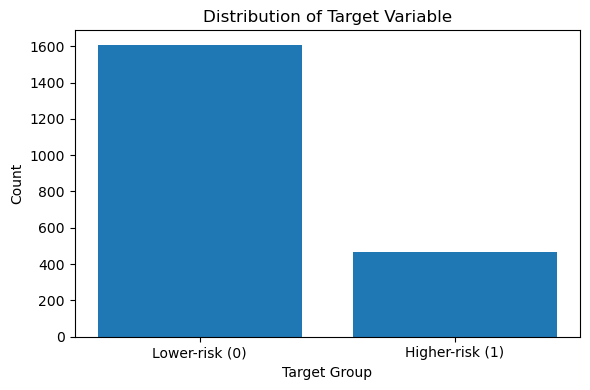

In [72]:
import matplotlib.pyplot as plt

# Count target values
target_counts = model_df['target'].value_counts().sort_index()

# Plot target distribution
plt.figure(figsize=(6, 4))
plt.bar(['Lower-risk (0)', 'Higher-risk (1)'], target_counts.values)

plt.xlabel('Target Group')
plt.ylabel('Count')
plt.title('Distribution of Target Variable')

plt.tight_layout()
plt.show()

From the figure, the lower-risk group is larger than the higher-risk group. This indicates that the target variable is somewhat imbalanced, although both classes are still represented in the dataset.